In [47]:
from typing import Dict, List, Optional,Literal
from typing import TypedDict,Annotated
from langgraph.graph import StateGraph, END
from langchain_core.messages import AIMessage
from langchain_community.tools import DuckDuckGoSearchResults as DDGS
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
import json
from langchain_core.pydantic_v1 import BaseModel,Field
import os
import dotenv
import re
from datetime import datetime, timedelta

In [48]:
dotenv.load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [49]:
wrapper = DuckDuckGoSearchAPIWrapper(time="w", max_results=15)
tool = DDGS(backend="news",api_wrapper=wrapper)
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.ddg_search.tool.DuckDuckGoSearchResults'>
duckduckgo_results_json


In [ ]:
# Define the article structure
class Article(TypedDict):
    title: str
    url: str
    date: str
    content: str
    source: str

# Define workflow state using TypedDict
class NewsroomState(TypedDict):
    topic: str
    searched_articles: List[Article]
    reported_articles: List[Article]
    edited_articles: List[Article]
    final_articles: List[Article]
    current_stage: Literal["search", "report", "edit", "review"]
    error: Optional[str]

# Initialize agents
model = ChatGroq(
        groq_api_key=GROQ_API_KEY, 
        model_name='llama3-8b-8192'
    )
search_tool = tool

def create_initial_state(topic: str) -> NewsroomState:
    """Create initial state for the workflow"""
    return {
        "topic": topic,
        "searched_articles": [],
        "reported_articles": [],
        "edited_articles": [],
        "final_articles": [],
        "current_stage": "search",
        "error": None
    }

def extract_json_from_response(content: str) -> List[Article]:
    try:
        # First attempt: direct JSON parsing
        return json.loads(content)
    except json.JSONDecodeError:
        # Second attempt: find JSON array in content
        json_match = re.search(r'\[[\s\S]*\]', content)
        if json_match:
            try:
                return json.loads(json_match.group())
            except json.JSONDecodeError:
                pass
    
    # Final attempt: structured parsing
    articles = []
    current_article = {}
    
    for line in content.split('\n'):
        if '"title":' in line:
            if current_article and all(k in current_article for k in Article.__annotations__):
                articles.append(current_article)
            current_article = {}
        
        for field in Article.__annotations__:
            if f'"{field}":' in line:
                value = line.split(':', 1)[1].strip().strip('",')
                current_article[field] = value
    
    if current_article and all(k in current_article for k in Article.__annotations__):
        articles.append(current_article)
    
    return articles

def update_state(state: NewsroomState, updates: dict) -> NewsroomState:
    new_state = state.copy()
    for key, value in updates.items():
        new_state[key] = value
    return new_state

# 1. Search Agent
def search_agent(state: NewsroomState) -> NewsroomState:
    """News Retrieval Search Agent"""
    search_prompt = f"""You are a News Retrieval Search Agent.
    Search for articles related to: {state['topic']}
    
    Requirements:
    - Minimum 10 high-quality articles
    - Filter out: off-topic, low-quality sources, duplicates, opinion pieces
    - Focus on factual reporting
    
    Return ONLY a JSON array of articles, exactly like this:
    [
        {{
            "title": "Article Title",
            "url": "https://...",
            "date": "YYYY-MM-DD",
            "content": "Article body...",
            "source": "Source Name"
        }}
    ]
    """
    
    try:
        search_results = search_tool.run(f"news {state['topic']}")
        response = model.invoke([HumanMessage(content=f"{search_prompt}\n\nSearch results:\n{search_results}")])
        articles = extract_json_from_response(response.content)
        
        if not articles:
            return update_state(state, {
                "error": "No valid articles found",
                "searched_articles": []
            })
        
        return update_state(state, {
            "searched_articles": articles,
            "current_stage": "report",
            "error": None
        })
    except Exception as e:
        return update_state(state, {
            "error": f"Search failed: {str(e)}",
            "searched_articles": []
        })

def reporter_agent(state: NewsroomState) -> NewsroomState:
    """News Reporter Agent"""
    if not state['searched_articles']:
        return update_state(state, {"error": "No articles to report on"})
    
    reporter_prompt = """You are a skilled News Reporter. Transform this article into an engaging, 
    unbiased story while maintaining accuracy. Focus on:
    - Clear and concise writing
    - Engaging narrative structure
    - Factual accuracy
    - Balanced perspective
    
    Return ONLY a JSON array with a single article, exactly like this:
    [
        {
            "title": "Original title - keep it",
            "url": "Original URL - keep it",
            "date": "Original date - keep it",
            "content": "Your rewritten content here...",
            "source": "Original source - keep it"
        }
    ]
    """
    
    try:
        reported_articles = []
        for article in state['searched_articles']:
            response = model.invoke([
                HumanMessage(content=f"{reporter_prompt}\n\nArticle:\n{json.dumps([article])}")
            ])
            
            processed_articles = extract_json_from_response(response.content)
            if processed_articles:
                reported_articles.extend(processed_articles)
        
        if not reported_articles:
            return update_state(state, {
                "error": "No articles were successfully processed",
                "reported_articles": []
            })
        
        return update_state(state, {
            "reported_articles": reported_articles,
            "current_stage": "edit",
            "error": None
        })
    except Exception as e:
        return update_state(state, {
            "error": f"Reporting failed: {str(e)}",
            "reported_articles": []
        })


def editor_agent(state: NewsroomState) -> NewsroomState:
    """News Editor Agent"""
    if not state['reported_articles']:
        return NewsroomState(**state, error="No articles to edit")
    
    editor_prompt = """You are a meticulous News Editor. Review and refine these articles for:
    - Clarity and readability
    - Logical structure
    - Grammatical accuracy
    - Consistent style
    - Engaging headlines
    Return ONLY a JSON array with a single article, exactly like this:
    [
        {
            "title": "Original title - keep it",
            "url": "Original URL - keep it",
            "date": "Original date - keep it",
            "content": "Your rewritten content here...",
            "source": "Original source - keep it"
        }
    ]
    Maintain the factual integrity while enhancing presentation.Don't include any string just return the response."""
    
    try:
        edited_articles = []
        for article in state['reported_articles']:
            response = model.invoke([
                HumanMessage(content=f"{editor_prompt}\n\nArticle:\n{json.dumps(article)}")
            ])
            print(f"{editor_prompt} Article: {json.dumps(article)}")
            print("response",response)
            edited_article = extract_json_from_response(response.content)
            
            print(edited_article)
            
            if edited_article:
                edited_articles.extend(edited_article)
        
        if not edited_articles:
            return update_state(state, {
                "error": "No articles were successfully processed",
                "edited_articles": []
            })
        
        return update_state(state, {
            "edited_articles": edited_articles,
            "current_stage": "review",
            "error": None
        })
    except Exception as e:
        return update_state(state, {
            "error": f"Reporting failed: {str(e)}",
            "edited_articles": []
        })
        
def log_processing(func):
    def wrapper(*args, **kwargs):
        print(f"\n{'='*50}")
        print(f"Now Processing: {func.__name__}")
        print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"{'='*50}")
        result = func(*args, **kwargs)
        print(f"\nCompleted: {func.__name__}")
        print(f"{'='*50}\n")
        return result
    return wrapper

# Modified newsroom editor with conditional branching
@log_processing
def newsroom_editor(state: NewsroomState) -> NewsroomState:
    """Newsroom Editor - Final Review and Approval with conditional branching"""
    if state.get('error'):
        print("⚠️ Error detected - Redirecting to search stage")
        return update_state(state, {"current_stage": "search"})

    if state.get('current_stage') == "review" and state.get('edited_articles'):
        review_prompt = """You are the Chief Newsroom Editor. Review these articles for:
        - Minimum 10 articles requirement
        - Source credibility
        - Content quality and insight
        - Writing style and engagement
        Note: if you see the starting lined as "Here is re written Json format artical","Here is re written article" etc. please kindly ignore and just focus on the content 
        Return a JSON response in this format:
        {
            "decision": "approve|reject",
            "reason": "specific reason for decision",
            "stage": "search|report|edit"
        }"""

        response = model.invoke([
            HumanMessage(content=f"{review_prompt}\n\nArticles:\n{json.dumps(state['edited_articles'], ensure_ascii=False)}")
        ])
        
        try:
            feedback = json.loads(response.content)
            print(f"📋 Editor's Decision: {feedback['decision']}")
            print(f"📝 Reason: {feedback['reason']}")
            
            if feedback['decision'] == 'approve':
                print("✅ Articles approved - Workflow complete")
                return update_state(state, {
                    "final_articles": state["edited_articles"],
                    "current_stage": "complete"
                })
            
            print(f"🔄 Articles need revision - Redirecting to {feedback['stage']} stage")
            return update_state(state, {"current_stage": feedback['stage']})
            
        except json.JSONDecodeError:
            print("⚠️ Invalid editor response - Defaulting to edit stage")
            return update_state(state, {"current_stage": "edit"})

    return state


workflow = StateGraph(NewsroomState)

# Define the edges
workflow.add_node("search", search_agent)
workflow.add_node("report", reporter_agent)
workflow.add_node("edit", editor_agent)
workflow.add_node("newsroom_editor", newsroom_editor)

workflow.set_entry_point("newsroom_editor")
# Connect the nodes
workflow.add_conditional_edges(
    "newsroom_editor",
    lambda x: x["current_stage"],
    {
        "search": "search",
        "report": "report",
        "edit": "edit",
        "complete": END
    }
)

workflow.add_edge("search", "newsroom_editor")
workflow.add_edge("report", "newsroom_editor")
workflow.add_edge("edit", "newsroom_editor")

app = workflow.compile()

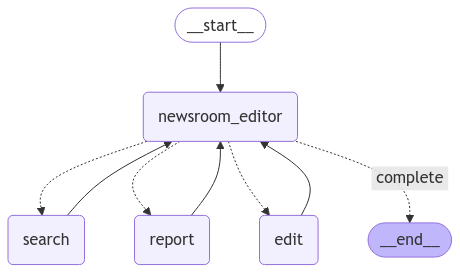

In [51]:
app

In [52]:
def search_agent(state: NewsroomState):
    """News Retrieval Search Agent"""
    search_prompt = f"""You are a News Retrieval Search Agent.
    Search for articles related to: {state['topic']}
    
    Requirements:
    - Minimum 10 high-quality articles
    - Filter out: off-topic, low-quality sources, duplicates, opinion pieces
    - Focus on factual reporting
    
    Return ONLY a JSON array of articles, exactly like this:
    [
        {{
            "title": "Article Title",
            "url": "https://...",
            "date": "YYYY-MM-DD",
            "content": "Article body...",
            "source": "Source Name"
        }}
    ]
    """
    
    # try:
    # search_results = search_tool.run(f"news {state['topic']}")
    struct_llm = model.with_structured_output(multiple_Article)
    response = struct_llm.invoke([HumanMessage(content=f"{search_prompt}\n\nSearch results:\n{search_results}")])
    print(response)
    # articles = extract_json_from_response(response.content)
    
    # if not articles:
    #     return update_state(state, {
    #         "error": "No valid articles found",
    #         "searched_articles": []
    #     })
    
    # return update_state(state, {
    #     "searched_articles": articles,
    #     "current_stage": "report",
    #     "error": None
    # })
    # except Exception as e:
    #     return update_state(state, {
    #         "error": f"Search failed: {str(e)}",
    #         "searched_articles": []
    #     })

In [53]:
topic = "Mahakumbh Mela"
in_state = create_initial_state(topic)
in_state

{'topic': 'Mahakumbh Mela',
 'searched_articles': [],
 'reported_articles': [],
 'edited_articles': [],
 'final_articles': [],
 'current_stage': 'search',
 'error': None}

In [54]:
search_agent(create_initial_state(topic))

TypeError: Object of type 'FieldInfo' is not JSON serializable